<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebook/Section02_Unsupervised_Learning/Chapter01_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DIMENSIONALITY REDUCTION**

In our previous chapter on **clustering**, we worked with data that had only **two features** per sample. This made it easy for us to **plot the data in a 2D space**, apply clustering algorithms like K-Means or DBSCAN, and visually confirm whether the clusters made sense.

We also mentioned that these clustering techniques can easily scale to **higher-dimensional data** — datasets with dozens or even hundreds of features. And that’s absolutely true: mathematically, nothing stops us from clustering in 20 or even 200 dimensions.

But here’s the catch: **how do we make sense of that many dimensions?**  
We can't *see* it. We can't *feel* it. And without that intuition, it’s easy to get lost.

Moreover, as we discussed earlier in the **supervised learning** section, throwing in more features isn’t always a good thing. More features often mean **more parameters** for our model to learn — and that raises the **risk of overfitting**. Your model might start memorizing noise or meaningless correlations instead of learning what actually matters.

And let’s leave overfitting aside for a moment — in the real world, **hardware** becomes your biggest bottleneck. Training frontier models like **GPT‑4** for example, has been estimated to cost **tens of millions of dollars**, primarily due to the enormous number of parameters, data, and GPU compute required.

> According to the paper *“The rising costs of training frontier AI models”* (Cottier et al., 2024), the **amortized cost of hardware and energy alone** for GPT‑4 training is estimated to be around **\$40 million**, while **total project-level expenses** are believed to be **well over \$100 million**.
>
> 📄 [The rising costs of training frontier AI models](https://arxiv.org/abs/2405.21015)

This highlights the value of techniques like dimensionality reduction — where fewer features can mean not only simpler, faster models but **massive savings** in real-world deployment.

So this is where **Dimensionality Reduction** steps in. It's the process of transforming high-dimensional data into a **lower-dimensional representation**, without losing the key patterns that make the data meaningful.

---

### **Why do we need it?**

- **Clarity:** We can't visualize 1000-dimensional space — but we *can* see beautiful patterns when projected to 2D or 3D.
- **Speed:** Fewer dimensions mean **faster computations** — not just for training but for inference too.
- **Noise Reduction:** Most high-dimensional data is filled with **redundant or irrelevant information**. Reducing dimensions removes the junk.
- **Overfitting Prevention:** Too many parameters make it easier for models to overfit. Fewer inputs = **simpler, more generalizable models**.
- **Lower Cost:** Fewer parameters = **less GPU usage**, less electricity, and reduced training time — a massive factor at scale.
- **Better Clustering:** When data is reduced into a compact, dense space, clustering algorithms often **perform better and more consistently**.
- **Feature Insight:** Sometimes, the new dimensions themselves reveal hidden truths — like discovering underlying topics in texts, or patterns in genetic expressions.

Dimensionality reduction helps us **see** and **work with** the data better — not by removing the information, but by condensing it into its most expressive form.

## **Principal Component Analysis (PCA)**

Imagine you're handed a spreadsheet with **hundreds of columns** — let's say it's customer data with age, income, spending habits, favorite product categories, time spent on the website, click behavior, and more.

But you know not all of these features are giving *unique* information: Age and income might be related, but people who spend more time browsing often click more too, so they both are basically following the same trace. These two features are just **echoes** of others.

That’s where **PCA** comes in.

Instead of looking at these features one by one, PCA rotates the entire coordinate system and asks:
> “Which **directions** in this tangled data cloud tell me the *most* about the shape of the data?”

Those directions are called the **Principal Components**.

Each Principal Component is a new "meta-feature" that **mixes the original features**, but in just the right way to capture the **maximum variation** in your data.

---

### **Think of it Like This:**

Let’s say you’re trying to **track a bird’s motion while flying**.

* If you place a camera **on the ground facing up** (looking at the bird from below), you might be able to measure how far the bird moves forward — but you’ll **lose information about how high it flies**.
* If instead you place a camera **right in front of the bird**, you can track how its **height changes**, but this time you’ll lose sight of its **forward or backward movement**.

Clearly, the way you view the scene affects **what you capture**.

But what if you place the camera **on the side**, at the perfect angle that captures both its forward movement *and* its height change?
Now, you're able to see the **most complete picture** in just two dimensions — without needing to see the full 3D space.

That’s exactly what PCA does: it **finds the best angle** to project high-dimensional data into a lower dimension — while **preserving the most information** possible.

You could also tilt the camera to a **diagonal front-side view**. You’d still capture both directions, but now the **motion doesn’t look as clear or realistic**. The bird’s speed and direction may seem distorted. That’s because you’re no longer aligned with the directions of **maximum variance**.

To understand what this “variance” really means, let’s move on to another example.

---

### **Capturing Group Photos**

Suppose you’re taking a group photo of 10 people standing in a line.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S02_C01/pca.png" width="600">
</div>

- If you snap the photo from the **side** of the line, everyone’s heads overlap. The photo captures **very little variation** in position — the differences are hidden.
- If you move a bit, you start to see more separation — still not great.
- But if you take the photo from the **front**, now every person is spaced out clearly — the image captures the **highest variance** in positions.

That’s what PCA does: it rotates the “camera” to capture your data from the **clearest angle**, so everything is **spread out** and easier to work with.

This is also **dimension reduction** in action — the real world is 3D, but the photo is 2D. Yet, the right projection captures almost everything that matters.

## **PCA Algorithm**

A high-level overview of how PCA works would be:

1. **Center the data**  
   Shift the data so the average of each feature is zero — this makes calculations cleaner.

2. **Build the Covariance Matrix**  
   This matrix tells you which features move together and how strongly.

3. **Find the Eigenvectors and Eigenvalues**  
   These give you the **axes of maximum variance** (Principal Components) and **how much** each one matters.

4. **Select Top k Components**  
   You keep the top directions (the ones with the highest eigenvalues) — these capture most of the signal.

---

### **The Principal Components**

Each Principal Component is:
- A **new axis** created from a **blend** of your original features.
- Chosen to maximize variance, meaning it captures **what’s different and important** in your data.

Think of it as inventing a new feature like:
> *PC1 = 0.6 × income + 0.3 × browsing time − 0.2 × complaint rate − 0.1 × refund requests*

...which might represent something like **engagement level** — a pattern that wasn’t clearly visible in any one feature but becomes obvious when combined smartly.

---

## **When Would You Actually Use PCA?**

Any time you have **too many features**, especially when:
- The features are **correlated**
- You want to **visualize high-dimensional data**
- You're preparing data for **clustering or classification**
- You want to **compress** or simplify without losing meaning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [ ]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvectors by eigenvalues descending
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Keep only the first n_components
        self.components = eigenvectors[:, :self.n_components]

    def transform(self, X):
        # Project data onto principal components
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

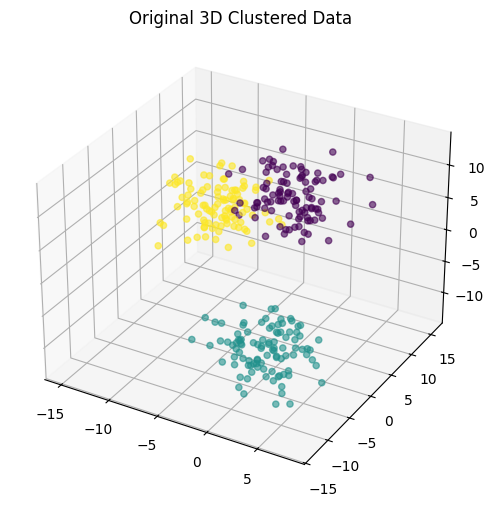

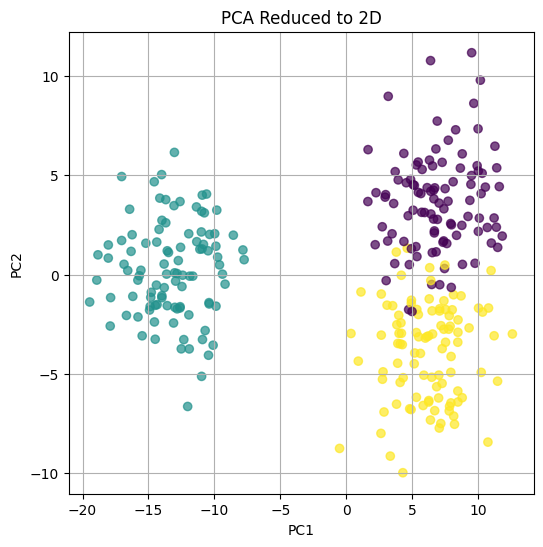

In [ ]:
# Generate 3D clustered data
X, y = make_blobs(n_samples=300, centers=3, n_features=3, cluster_std=2.5, random_state=42)

# Plot original 3D data with clusters
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis', alpha=0.6)
ax.set_title("Original 3D Clustered Data")
plt.show()

# Fit PCA to reduce from 3D -> 2D
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title("PCA Reduced to 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.show()

### **PCA Example: Students’ Grades**

Imagine you have student grade data across **six subjects**: Math, Physics, Chemistry, Biology, Geography, and History. Each subject is a **feature** — a dimension. So with six subjects, each student is a point in **6D space**. Visualizing or analyzing in 6D is *impossible* for humans — even 3D plots can feel messy and confusing.

Now, a naive solution would be to just choose two subjects and plot those — say, Math vs. History.
But that throws away **4 out of 6 features** — a lot of useful information.

Instead, we use **PCA** to compress the data **intelligently**:

* **PC1 (First Principal Component)** might be something like:
  `PC1 = 0.5 × Math + 0.4 × Physics + 0.3 × Chemistry − 0.2 × History − 0.1 × Geography`
  So students with high PC1 values are likely strong in STEM subjects and less so in humanities.

* **PC2 (Second Principal Component)** could be something like:
  `PC2 = 0.5 × History + 0.4 × Geography − 0.3 × Math`
  This might reflect students with strengths in Social Sciences, regardless of their STEM scores.

So instead of 6 separate axes, you now have **2 smarter axes** that:

* Combine your original features,
* Explain the **maximum variance** possible,
* Help you **see clusters, trends, or outliers** clearly in 2D.

This way, you keep most of the useful information — but in a much simpler form that still tells you:

* What kind of learners exist in your dataset,
* Whether some students are “balanced” across domains,
* Or if others lean strongly toward specific academic areas.

,Math,Physics,Chemistry,Biology,Geography,History
0,92.450712,77.926035,87.715328,97.845448,56.487699,51.487946
1,108.688192,91.511521,70.957884,83.138401,53.048735,48.014054
2,88.629434,51.300796,52.126233,66.565687,44.807533,59.713710
3,71.379639,58.815444,99.984732,71.613355,61.012923,33.628777
4,76.834259,81.663839,60.735096,80.635470,50.990420,50.624594


Original shape: (200, 6)
Reduced shape: (200, 2)


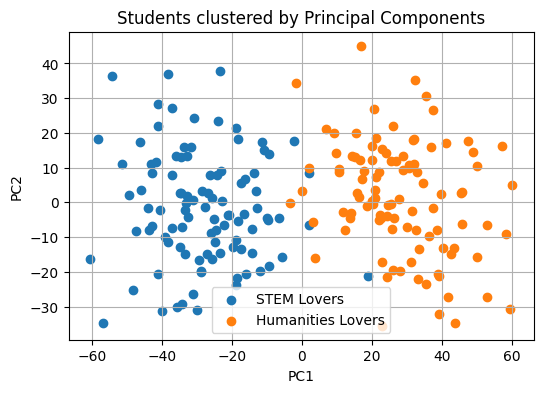

In [ ]:
# Simulate data for 200 students: [Math, Physics, Chemistry, Biology, Geography, History]
np.random.seed(42)
student_per_cluster = 100

# STEM scores: generally higher for some students
stem_students = np.random.normal(loc=[85, 80, 78, 75, 60, 55], scale=15, size=(student_per_cluster, 6))
# Humanities-heavy students
humanities_students = np.random.normal(loc=[60, 55, 58, 60, 80, 85], scale=15, size=(student_per_cluster, 6))

# Combine them
students = np.vstack([stem_students, humanities_students])

# Create DataFrame
subjects = ['Math', 'Physics', 'Chemistry', 'Biology', 'Geography', 'History']
df = pd.DataFrame(students, columns=subjects)

display(df.head())

# Apply PCA to reduce 6D -> 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.values)

print(f"Original shape: {df.shape}")
print(f"Reduced shape: {X_pca.shape}")

# Visualize
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:student_per_cluster, 0], X_pca[:student_per_cluster, 1], label='STEM Lovers')
plt.scatter(X_pca[student_per_cluster:, 0], X_pca[student_per_cluster:, 1], label='Humanities Lovers')
plt.title("Students clustered by Principal Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

### **Image Compression**

In this example, we load six grayscale face images and apply **PCA** to each one individually. PCA reduces the number of dimensions (pixels) by keeping only the **top `n` principal components**, which capture most of the important variation in the image.

* The **original images** are 350×300 pixels → **105,000 pixels (parameters)** per image.
* After PCA, each image is represented using only **n components (20 by default)**, plus a mean vector — reducing the image to **a tiny fraction of its original size** while keeping the structure recognizable.

But **how does PCA know what to keep?**  
PCA identifies patterns in the data by analyzing which **directions (linear combinations of pixels)** show the most **variation** — in faces, that might be the curve of the jaw, the position of eyes, or shadows under the nose. It keeps those directions with the highest variance and discards the rest. The result is a **compressed version** that captures the essential **shapes and structures** of faces without storing every pixel individually.

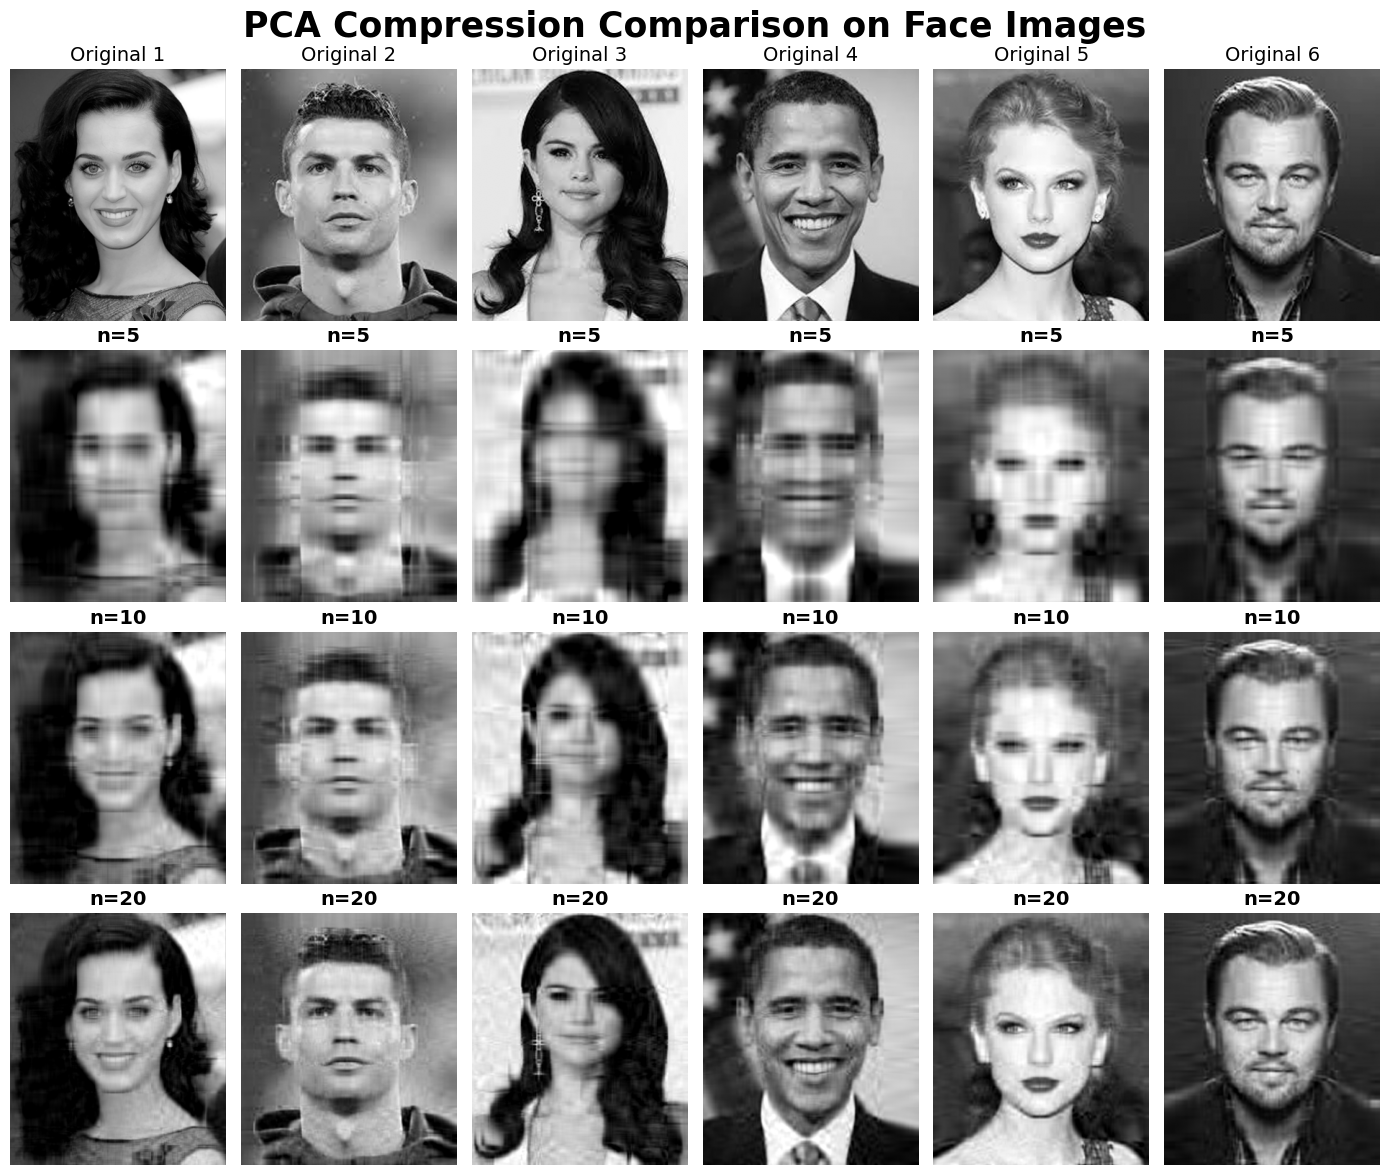

In [ ]:
from sklearn.decomposition import PCA
import requests
from PIL import Image
from io import BytesIO

# Test with multiple component values
n_components_list = [5, 10, 20]

# Helper to apply PCA to each channel
def compress_image_pca(img_array, n_components=50):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(img_array)
    restored = pca.inverse_transform(reduced)
    return np.clip(restored, 0, 255).astype(np.uint8)

# Load all 6 images
originals = []
for i in range(1, 7):
    url = f'https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S02_C01/faces/face{i}.png'
    img = Image.open(BytesIO(requests.get(url).content)).convert('L')
    img_np = np.array(img)
    originals.append(img_np)

# Create a figure with subplots for each n_components value
fig, axes = plt.subplots(len(n_components_list) + 1, 6, figsize=(14, 12))

# Plot originals in the first row
for i in range(6):
    axes[0, i].imshow(originals[i], cmap='gray')
    axes[0, i].set_title(f'Original {i+1}', fontsize=14)
    axes[0, i].axis('off')

# Plot reconstructed images for each n_components value
for row_idx, n in enumerate(n_components_list, start=1):
    reconstructed = []
    for i in range(6):
        rec_img = compress_image_pca(originals[i], n_components=n)
        reconstructed.append(rec_img)

        axes[row_idx, i].imshow(rec_img, cmap='gray')
        axes[row_idx, i].set_title(f'n={n}', fontsize=14, fontweight='bold')
        axes[row_idx, i].axis('off')

plt.suptitle("PCA Compression Comparison on Face Images", fontsize=25, fontweight='bold')
plt.tight_layout()
plt.show()

## **t-distributed Stochastic Neighbor Embedding (t-SNE)**

PCA gave us our first step into the world of **dimensionality reduction** — it projects data into directions of maximum variance, keeping the **most “spread out” information** while reducing dimensions. But PCA is inherently **linear**. It fails to capture the **curved or complex structures** that often exist in real-world data.That’s where **t-SNE** (t-distributed Stochastic Neighbor Embedding) comes in.

While PCA tries to **preserve global structure** (the overall shape), t-SNE focuses on preserving **local neighborhoods** — it wants similar things to stay close, even if the overall structure is distorted. This makes t-SNE perfect for **visualizing clusters** in datasets like handwritten digits, where small nonlinear patterns matter a lot.

---

### **Digits Dataset: PCA vs. t-SNE**

In the PCA plot, we still see some clustering, but digits often overlap — because PCA treats the digit images as flat patterns and keeps only the broadest trends.

In contrast, t-SNE **pulls similar digits tightly together** and **pushes different ones apart**, forming beautiful, dense clusters. It’s like reshaping space so that each digit lives in its own island.

Even though t-SNE doesn’t tell us what the axes mean, it gives us something far more powerful: **insight into similarity**. It shows that digits like **0s**, **1s**, and **9s** have distinct “shapes” in high-dimensional space — and that’s the kind of understanding PCA alone could never give.

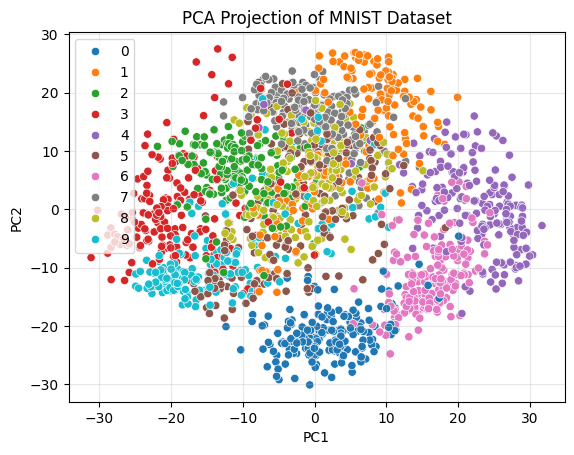

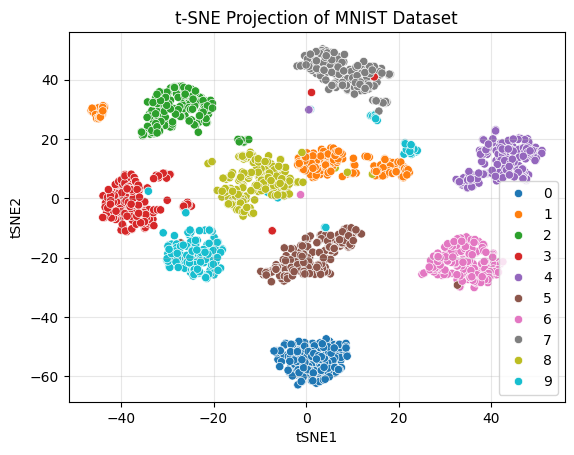

In [ ]:
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
import seaborn as sns

n = 20

# Load dataset
digits = load_digits()
X = digits.data
y = digits.target

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10')
plt.title('PCA Projection of MNIST Dataset')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab10')
plt.title('t-SNE Projection of MNIST Dataset')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##**Uniform Manifold Approximation and Projection(UMAP)**

UMAP is a powerful, modern dimensionality reduction technique designed to preserve both **local structure** (like t-SNE) and **global structure** (like PCA). It's especially useful when we want to understand the shape and structure of **high-dimensional datasets**—like images, text embeddings, or biological data.

---

###**How UMAP Works (Intuitively)**

1. **Neighborhood Preservation**:
   UMAP constructs a graph where each data point is connected to its nearest neighbors in high dimensions—this captures **local patterns**.

2. **Low-Dimensional Mapping**:
   It then tries to build a **similar graph** in 2D or 3D space where those neighborhood relationships are still maintained.

3. **Optimization**:
   Using clever math (based on topology & geometry), UMAP tries to **minimize the difference** between the original and reduced graph structures.

---

###**Why UMAP Is So Powerful**

* **Captures local clusters well** (like t-SNE)
* **Preserves global structure better** (unlike t-SNE)
* **Faster and more scalable** than t-SNE
* **Works with any distance metric** (great for text, images, audio, etc.)
* Can even be used for **supervised tasks** (like classification boundaries!)

---

###**UMAP vs PCA vs t-SNE (Fashion-MNIST Example)**

In our plots:

* **PCA** spreads the data based on variance, but **can't form clear clusters** for each class.
* **t-SNE** makes beautiful clusters, but doesn't always keep the **global shape** of data.
* **UMAP** balances both: it shows **clear clusters** for each clothing item *and* preserves their relationships across the full dataset.

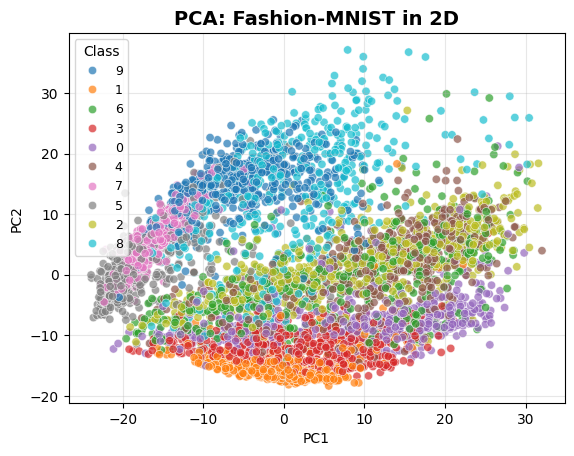

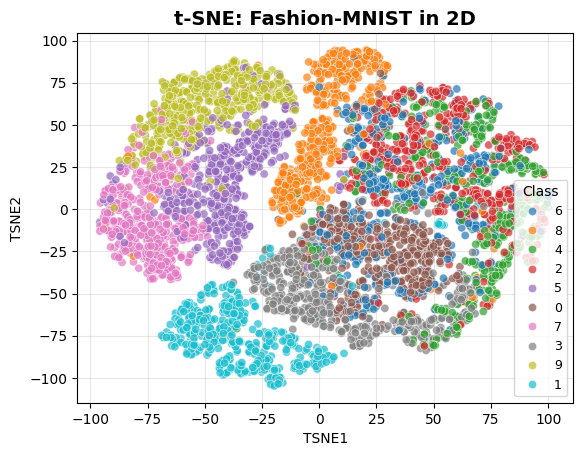

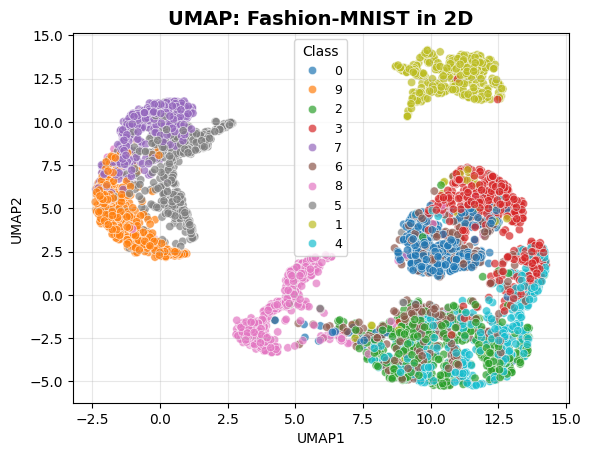

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import umap
from sklearn.preprocessing import StandardScaler

# Load Fashion-MNIST
fashion_mnist = fetch_openml(name="Fashion-MNIST", version=1, as_frame=False)
X = fashion_mnist.data
y = fashion_mnist.target

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["label"] = y
sns.scatterplot(data=df_pca.sample(5000), x="PC1", y="PC2", hue="label", palette="tab10", alpha=0.7)
plt.title("PCA: Fashion-MNIST in 2D", fontsize=14, fontweight='bold')
plt.legend(loc='best', title='Class', fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
df_tsne = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
df_tsne["label"] = y
sns.scatterplot(data=df_tsne.sample(5000), x="TSNE1", y="TSNE2", hue="label", palette="tab10", alpha=0.7)
plt.title("t-SNE: Fashion-MNIST in 2D", fontsize=14, fontweight='bold')
plt.legend(loc='best', title='Class', fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# UMAP
umap_model = umap.UMAP(n_components=2)
X_umap = umap_model.fit_transform(X_scaled)
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["label"] = y
sns.scatterplot(data=df_umap.sample(5000), x="UMAP1", y="UMAP2", hue="label", palette="tab10", alpha=0.7)
plt.title("UMAP: Fashion-MNIST in 2D", fontsize=14, fontweight='bold')
plt.legend(loc='best', title='Class', fontsize=9)
plt.grid(alpha=0.3)
plt.show()

##**Closing This Chapter**

We started with shadows — blurry reductions of complex data — and learned how to find the *right angle* to see the world more clearly. With PCA, t-SNE, and UMAP, we’ve discovered that even in a sea of dimensions, structure hides beneath. Patterns, clusters, meaning — all waiting to be revealed when we ask the right questions, and look from the right perspective.  
We also shouldn't forget that all of these were taking place in a dataset with no labels (**human's supervision**). We also covered clustering with different techniques in this chapter which was another important concept of *Unsupervised learning*.

---

### 🚀 **What’s Next?**
> **Reinforcement Learning**

Now that we’ve learned how to understand the *structure* of data, it’s time to build agents that **act** in the world. Reinforcement Learning is the field where machines learn by **trial, error, and reward** — like a child learning to walk, a robot can learn to strategize, optimize, and succeed… even without being told how.